**Latihan Word Embedding dengan menggunakan GloVe dan FastText**

Import library dan load dataset

dataset link: https://www.kaggle.com/datasets/muhammetakkurt/truth-social-reactions-to-trumps-iran-war-posts-s?resource=download&select=comments.csv

In [2]:
import kagglehub
import pandas as pd

df = pd.read_csv("data/comments.csv")  # sesuaikan
df = df[['content_clean']]  # ambil kolom teks saja
df.head(10)

,content_clean
0,God bless our military! 🙏❤️🇺🇸
1,NaN
2,#WeWantTermLimits #XTeam #MH8
3,NaN
4,We are not the same!
5,NaN
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...
7,💥Never forget how this began! The world thanks...
8,🔥☄️💥
9,NaN


Drop Null di dataset

In [3]:
df_cleaned = df.dropna()
df_cleaned

,content_clean
0,God bless our military! 🙏❤️🇺🇸
2,#WeWantTermLimits #XTeam #MH8
4,We are not the same!
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...
7,💥Never forget how this began! The world thanks...
...,...
242253,Isaiah 14:13–14. Listen to Lucifer talk. “I wi...
242254,America has your back sir!
242255,Thank you for protecting Americans
242256,That’s my PRESIDENT


Pre Processin and Tokenization

In [4]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

df_cleaned['tokens'] = df_cleaned['content_clean'].astype(str).apply(clean_text)
df_cleaned

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20640\931086130.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['tokens'] = df_cleaned['content_clean'].astype(str).apply(clean_text)


,content_clean,tokens
0,God bless our military! 🙏❤️🇺🇸,"[god, bless, military]"
2,#WeWantTermLimits #XTeam #MH8,"[wewanttermlimits, xteam, mh]"
4,We are not the same!,[]
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...,"[isnt, wonderful, trust, president, make, best..."
7,💥Never forget how this began! The world thanks...,"[never, forget, began, world, thanks, presiden..."
...,...,...
242253,Isaiah 14:13–14. Listen to Lucifer talk. “I wi...,"[isaiah, listen, lucifer, talk, ascend, heaven..."
242254,America has your back sir!,"[america, back, sir]"
242255,Thank you for protecting Americans,"[thank, protecting, americans]"
242256,That’s my PRESIDENT,"[thats, president]"


Menggunakan Library Text Blob untuk segmentasi Sentiment

In [6]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.0 kB 7.8 MB/s eta 0:00:01
   --------------------------------- ------ 524.3/625.0 kB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 853.6 kB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(" ".join(text)).sentiment.polarity
    if polarity > 0:
        return 1
    elif polarity < 0:
        return -1
    else:
        return 0

df_cleaned['label'] = df_cleaned['tokens'].apply(get_sentiment)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20640\3075599467.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['label'] = df_cleaned['tokens'].apply(get_sentiment)


In [8]:
df_cleaned

,content_clean,tokens,label
0,God bless our military! 🙏❤️🇺🇸,"[god, bless, military]",-1
2,#WeWantTermLimits #XTeam #MH8,"[wewanttermlimits, xteam, mh]",0
4,We are not the same!,[],0
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...,"[isnt, wonderful, trust, president, make, best...",1
7,💥Never forget how this began! The world thanks...,"[never, forget, began, world, thanks, presiden...",1
...,...,...,...
242253,Isaiah 14:13–14. Listen to Lucifer talk. “I wi...,"[isaiah, listen, lucifer, talk, ascend, heaven...",-1
242254,America has your back sir!,"[america, back, sir]",0
242255,Thank you for protecting Americans,"[thank, protecting, americans]",0
242256,That’s my PRESIDENT,"[thats, president]",0


In [9]:
import urllib.request
import zipfile

url = "https://nlp.stanford.edu/data/glove.6B.zip"
urllib.request.urlretrieve(url, "glove.zip")

with zipfile.ZipFile("glove.zip", 'r') as zip_ref:
    zip_ref.extractall("glove")

print("Done!")

Done!


Load GloVe Model

In [10]:
import numpy as np

embeddings_index = {}

with open("glove.6B.100d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

Sentence Vector pakai average word vector



In [11]:
def sentence_vector_glove(tokens):
    vectors = []
    for word in tokens:
        if word in embeddings_index:
            vectors.append(embeddings_index[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_glove = np.array(df_cleaned['tokens'].apply(sentence_vector_glove).tolist())
y = df_cleaned['label'].values


Split data Train dan Test GloVe

In [12]:
from sklearn.model_selection import train_test_split

X_train_g, X_test_g, y_train, y_test = train_test_split(X_glove, y, test_size=0.2)

Latih Model dengan Machine Learning

In [13]:
from sklearn.linear_model import LogisticRegression

model_glove = LogisticRegression(max_iter=200)
model_glove.fit(X_train_g, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [ ]:
from sklearn.svm import SVC

svm_glove = SVC()
svm_glove.fit(X_train_g, y_train)

Evaluasi

In [ ]:
from sklearn.metrics import classification_report

y_pred_glove = model_glove.predict(X_test_g)

print("=== GloVe ===")
print(classification_report(y_test, y_pred_glove))


=== GloVe ===
              precision    recall  f1-score   support

          -1       0.61      0.46      0.53     10521
           0       0.68      0.74      0.71     18750
           1       0.65      0.67      0.66     14990

    accuracy                           0.65     44261
   macro avg       0.64      0.63      0.63     44261
weighted avg       0.65      0.65      0.65     44261



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_glove)
print("Accuracy:", accuracy)

Accuracy: 0.6526739115700052


[[ 4885  3153  2483]
 [ 1783 13898  3069]
 [ 1365  3520 10105]]


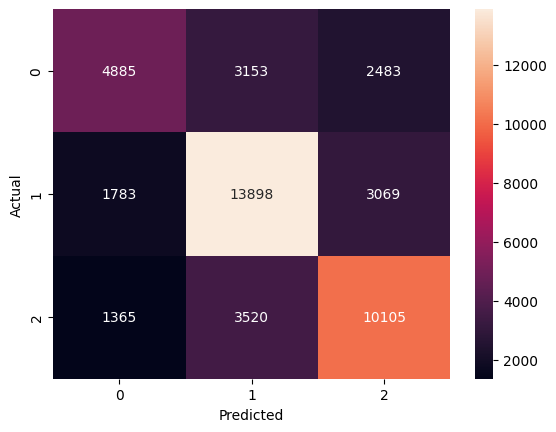

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_glove)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Install Gensim

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00


Load Model FastText Sederhana

In [ ]:
from gensim.models import FastText

sentences = df_cleaned['tokens'].tolist()

ft_model = FastText(sentences, vector_size=100, window=5, min_count=2)

Sentence Vector pakai average word vector


In [ ]:
def sentence_vector_ft(tokens):
    vectors = []
    for word in tokens:
        if word in ft_model.wv:
            vectors.append(ft_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_ft = np.array(df_cleaned['tokens'].apply(sentence_vector_ft).tolist())

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653911 sha256=7d885bd5b76ad18d29b3ea6caa22586130fe1b1c86207a9376253b4c7fa238d2
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


Split Training dan Test Data

In [ ]:
X_train_f, X_test_f, _, _ = train_test_split(X_ft, y, test_size=0.2)

Modeling

In [ ]:
model_ft = LogisticRegression(max_iter=200)
model_ft.fit(X_train_f, y_train)

LogisticRegression(max_iter=200)

In [ ]:
svm_ft = SVC()
svm_ft.fit(X_train_f, y_train)

SVC()

Evaluation

In [ ]:
y_pred_ft = model_ft.predict(X_test_f)

In [ ]:
print("=== FastText ===")
print(classification_report(y_test, y_pred_ft))

=== FastText ===
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00     10521
           0       0.42      1.00      0.59     18750
           1       0.31      0.00      0.00     14990

    accuracy                           0.42     44261
   macro avg       0.25      0.33      0.20     44261
weighted avg       0.29      0.42      0.25     44261



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_ft)
print("Accuracy:", accuracy)

Accuracy: 0.42337498023090303


[[    0 10493    28]
 [    0 18706    44]
 [    0 14957    33]]


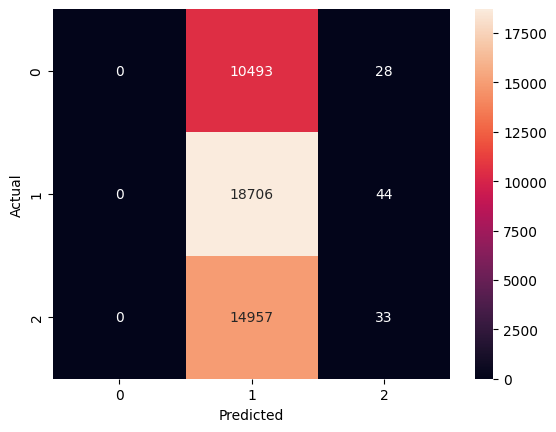

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_ft)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()